# COVID-19 Statistics Analysis (Enhanced)
This notebook presents an attractive and detailed analysis of COVID-19 statistics in India, covering confirmed cases, trends, vaccinations, testing, and positivity rates with insightful visualizations.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set attractive plotting style
sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.size"] = 12

## Q1. Which 10 Indian states or union territories recorded the highest cumulative number of confirmed COVID-19 cases on their latest available reporting date?
***Dataset: covid_19_india.csv***

C:\Users\soura\AppData\Local\Temp\ipykernel_6240\2782816336.py:36: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_cases["Date"] = pd.to_datetime(


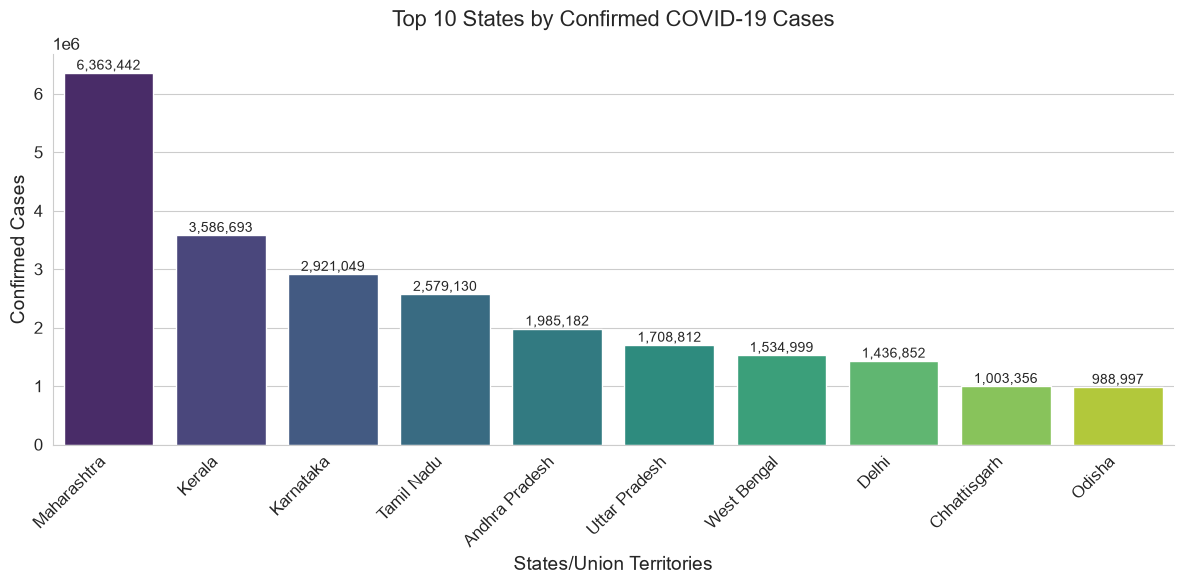

In [2]:
#---------------------------------
# STEP 1: Load the COVID-19 dataset
#----------------------------------

# Read the CSV file and store it inside the df_cases DataFrame
df_cases = pd.read_csv("covid_19_india.csv")

df_cases["State/UnionTerritory"] = (
    
    # Select the State/UnionTerritory column
    df_cases["State/UnionTerritory"]
    
    # Convert all values into string format
    .astype(str)
    
    # Remove extra spaces from the beginning and end
    # Example: " Karnataka " becomes "Karnataka"
    .str.strip()
    
    # Remove star symbols from state names
    # Example: "Maharashtra***" becomes "Maharashtra"
    .str.replace("*", "", regex=False)
    
    # Correct possible spelling mistakes
    .replace({
        "Karanataka": "Karnataka",
        "Maharastra": "Maharashtra"
    })
)

#----------------------------------------------------
# STEP 2: Convert the Date column into datetime format
#----------------------------------------------------

# Convert the Date column from text format into proper date format
df_cases["Date"] = pd.to_datetime(
    
    # Column that contains the dates
    df_cases["Date"],
    
    # The dates are written as day-month-year
    dayfirst=True,
    
    # Invalid dates will become NaT instead of producing an error
    errors="coerce"
)

#---------------------------------
# STEP 3: Sort the dataset by date
#---------------------------------

# Sort all records from the oldest date to the newest date
df_cases = df_cases.sort_values("Date")

#---------------------------------------------------
# STEP 4: Keep only the latest record of every state
#---------------------------------------------------

# A state may appear many times because the dataset contains daily COVID-19 records.

# drop_duplicates() keeps only one row for each state.
latest_cases = df_cases.drop_duplicates(
    
    # Check duplicate values using the state name
    subset="State/UnionTerritory",
    
    # Keep the last record because the data was sorted by date
    # The last record represents the latest available date
    keep="last"
)
#---------------------------------
# STEP 5: Select the top 10 states
#---------------------------------

# nlargest() selects the 10 rows having the highest
# values in the Confirmed column

top10_cases = latest_cases.nlargest(10,"Confirmed")

#-------------------------------
# STEP 6: Create the graph area
#-------------------------------

# Create a figure and axes for the graph
# figsize=(12, 6) means: Width  = 12 inches, Height = 6 inches

fig, ax = plt.subplots(figsize=(12, 6))

#-----------------------------
# STEP 7: Create the bar chart
#-----------------------------

bars = sns.barplot(
    
    # Data used for the graph
    data=top10_cases,
    
    # State names will be displayed on the x-axis
    x="State/UnionTerritory",
    
    # Confirmed cases will be displayed on the y-axis
    y="Confirmed",
    
    # Give each state a separate colour
    hue="State/UnionTerritory",
    
    # Apply the viridis colour palette
    palette="viridis",
    
    # Hide the legend because state names are already
    # displayed on the x-axis
    legend=False,
    
    # Draw the graph inside the axes created earlier
    ax=ax
)

#----------------------------------------
# STEP 8: Add graph title and axis labels
#----------------------------------------

# Add the title of the graph
ax.set_title("Top 10 States by Confirmed COVID-19 Cases",fontsize=16,pad=20)

# Add the x-axis label
ax.set_xlabel("States/Union Territories",fontsize=14)

# Add the y-axis label
ax.set_ylabel("Confirmed Cases",fontsize=14)

#-------------------------------
# STEP 9: Rotate the state names
#-------------------------------

# Rotate state names by 45 degrees so that they do not overlap
# ha="right" aligns the names towards the right side

plt.xticks(rotation=45, ha="right")

#------------------------------------------------------
# STEP 10: Display confirmed-case values above each bar
#------------------------------------------------------

# bars.patches contains all the individual bars in the graph
for bar in bars.patches:
    
    # Get the height of the current bar
    # The height represents the number of confirmed cases
    height = bar.get_height()

    # Write the confirmed-case value above the current bar
    ax.text(
        
        # Find the horizontal centre of the bar
        bar.get_x() + bar.get_width() / 2,
        
        # Place the text at the top of the bar
        height,
        
        # Format the number using commas
        # Example: 6363442 becomes 6,363,442
        f"{height:,.0f}",
        
        # Align the text horizontally at the centre
        ha="center",
        
        # Place the text just above the bar
        va="bottom",
        
        # Set the text size
        fontsize=10
    )

#--------------------------------------
# STEP 11: Improve the graph appearance
#--------------------------------------

# Remove the top and right borders of the graph
sns.despine()

# Automatically adjust the spacing so labels do not get cut
plt.tight_layout()
#---------------------------------
# STEP 12: Display the final graph
#---------------------------------
plt.show()

### Insights (Top 10 States by Confirmed Cases)
- **Worst Hit States**: States like Maharashtra, Kerala, and Karnataka typically lead in confirmed cases due to higher population density and better testing infrastructure
- **Geographic Trend**: Southern and Western states often report higher case counts compared to other regions
- **Scale**: The top states have case counts in the millions, indicating the widespread impact of the pandemic

## Q2. How did the cumulative numbers of confirmed, cured and death cases change over time across India?
***Dataset: covid_19_india.csv***

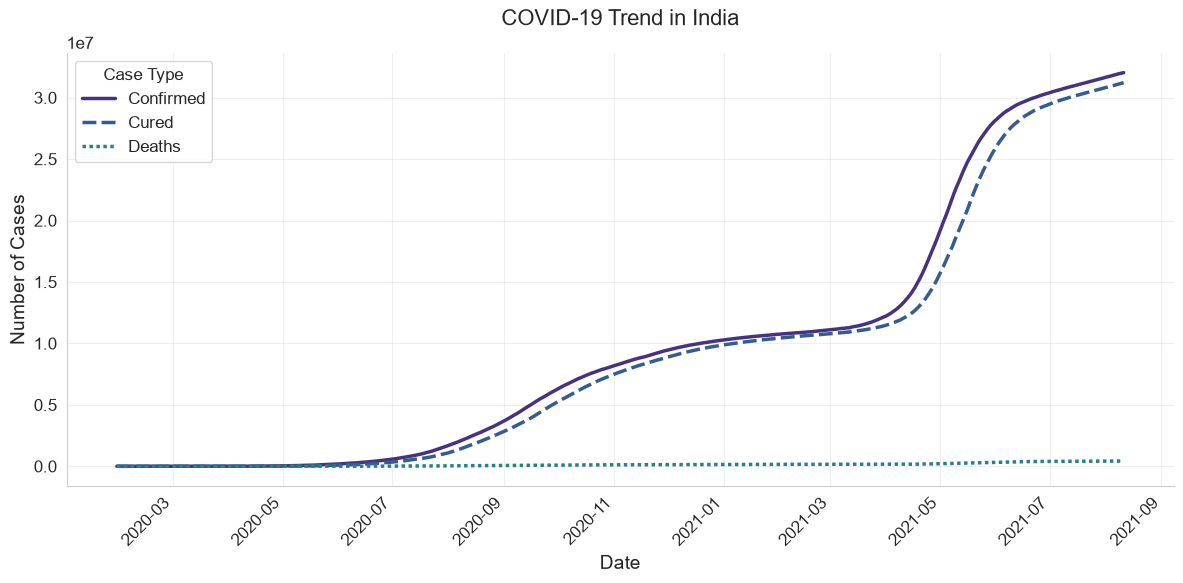

In [3]:
# ---------------------------------------------------------
# STEP 1: Calculate the total COVID-19 cases for each date
# ---------------------------------------------------------

# groupby("Date") groups all rows that have the same date.
# [["Confirmed", "Cured", "Deaths"]] selects only these three columns.
# sum() adds the values of all states and union territories for each date.
india_trend = (df_cases.groupby("Date")[["Confirmed", "Cured", "Deaths"]].sum())

# ---------------------------------------------------------
# STEP 2: Create the figure and plotting area
# ---------------------------------------------------------

# plt.subplots() creates:
# fig -> the complete figure or chart window
# ax  -> the plotting area where the graph will be drawn
fig, ax = plt.subplots(figsize=(12, 6))

# ---------------------------------------------------------
# STEP 3: Create the line graph
# ---------------------------------------------------------

# sns.lineplot() creates a line graph using Seaborn.
# data=india_trend tells Seaborn which DataFrame to use.
# ax=ax tells Seaborn to draw the graph inside the axes created above.
# linewidth=2.5 makes the lines thicker and easier to see.
sns.lineplot(data=india_trend,ax=ax,linewidth=2.5)

# ---------------------------------------------------------
# STEP 4: Add a title to the graph
# ---------------------------------------------------------

# set_title() adds the main heading of the graph.
# fontsize=16 controls the size of the title.
# pad=20 adds space between the title and the graph.
ax.set_title("COVID-19 Trend in India",fontsize=16,pad=20)

# ---------------------------------------------------------
# STEP 5: Add a label to the x-axis
# ---------------------------------------------------------

# The x-axis displays the dates.
# fontsize=14 controls the size of the label.
ax.set_xlabel("Date",fontsize=14)

# ---------------------------------------------------------
# STEP 6: Add a label to the y-axis
# ---------------------------------------------------------

# The y-axis displays the total number of COVID-19 cases.
ax.set_ylabel("Number of Cases",fontsize=14)

# ---------------------------------------------------------
# STEP 7: Add the legend
# ---------------------------------------------------------

# The legend identifies the three lines:
# Confirmed, Cured, and Deaths.
# fontsize=12 controls the size of the legend text.
ax.legend(title="Case Type",fontsize=12)

# ---------------------------------------------------------
# STEP 8: Add grid lines
# ---------------------------------------------------------

# grid(True) turns on the grid lines.
# alpha=0.3 makes the grid lines light and transparent.
ax.grid(True,alpha=0.3)

# ---------------------------------------------------------
# STEP 9: Rotate the date labels
# ---------------------------------------------------------

# rotation=45 rotates the date values by 45 degrees.
# ha="right" aligns the date labels toward the right.
# This makes long date labels easier to read.
plt.xticks(rotation=45,ha="right")

# ---------------------------------------------------------
# STEP 10: Remove unnecessary graph borders
# ---------------------------------------------------------

# sns.despine() removes the top and right borders.
# This gives the graph a cleaner appearance.
sns.despine()

# ---------------------------------------------------------
# STEP 11: Adjust the graph layout
# ---------------------------------------------------------

# tight_layout() automatically adjusts the spacing.
# It prevents labels, dates, and titles from overlapping.
plt.tight_layout()

# ---------------------------------------------------------
# STEP 12: Display the final graph
# ---------------------------------------------------------

# plt.show() displays the completed line graph.
plt.show()

### Insights (Case Trends Over Time)
- **Growth Pattern**: Confirmed cases show a steep upward trend followed by stabilization as recovery rates increase
- **Recovery Success**: The number of cured cases closely tracks and eventually surpasses confirmed cases, indicating effective healthcare response
- **Mortality**: Death cases show a much slower growth rate compared to confirmed and cured cases, suggesting lower mortality rates over time

## Q3. How did the cumulative administration of first and second COVID-19 vaccine doses progress over time in India?
***Dataset: covid_vaccine_statewise.csv***

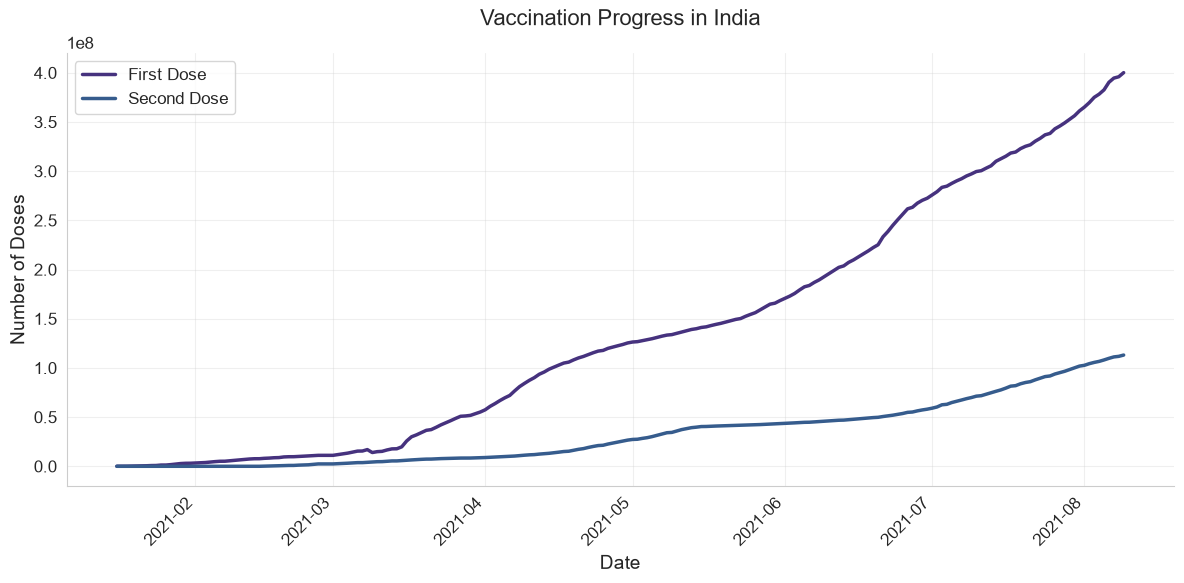

In [4]:
# ---------------------------------------------------------
# STEP 1: Load the vaccination dataset
# ---------------------------------------------------------

# pd.read_csv() reads the CSV file and stores it in a Pandas DataFrame.
# The DataFrame is saved in the variable df_vaccine.
df_vaccine = pd.read_csv("covid_vaccine_statewise.csv")


# ---------------------------------------------------------
# STEP 2: Convert the date column into datetime format
# ---------------------------------------------------------

# pd.to_datetime() converts the "Updated On" column from text
# into proper date values that Python can understand.
#
# dayfirst=True means the date format is read as:
# Day-Month-Year, for example: 15-04-2021.
df_vaccine["Updated On"] = pd.to_datetime(df_vaccine["Updated On"],dayfirst=True)

# ---------------------------------------------------------
# STEP 3: Select only the vaccination data for India
# ---------------------------------------------------------

# df_vaccine["State"] == "India" checks every row in the State column.
# It returns True for rows where the State value is India.
#
# df_vaccine[...] keeps only those rows.
india_vaccine = df_vaccine[df_vaccine["State"] == "India"]

# ---------------------------------------------------------
# STEP 4: Create the figure and plotting area
# ---------------------------------------------------------

# plt.subplots() creates:
# fig -> the complete figure or chart
# ax  -> the plotting area where the lines are drawn
#
# figsize=(12, 6) makes the graph 12 inches wide
# and 6 inches high.
fig, ax = plt.subplots(figsize=(12, 6))

# ---------------------------------------------------------
# STEP 5: Plot the First Dose vaccination progress
# ---------------------------------------------------------

# sns.lineplot() creates a line graph.
# x="Updated On" places dates on the horizontal axis.
# y="First Dose Administered" places first-dose values on the vertical axis.
# data=india_vaccine tells Seaborn which DataFrame to use.
# label="First Dose" sets the name displayed in the legend.
# linewidth=2.5 controls the thickness of the line.
# ax=ax draws the line inside the axes created above.
sns.lineplot(x="Updated On",y="First Dose Administered",data=india_vaccine,label="First Dose",linewidth=2.5,ax=ax)


# ---------------------------------------------------------
# STEP 6: Plot the Second Dose vaccination progress
# ---------------------------------------------------------

# This creates another line on the same graph.
# The x-axis again contains the dates.
# The y-axis contains the number of second doses administered.
# label="Second Dose" identifies this line in the legend.
sns.lineplot(x="Updated On",y="Second Dose Administered",data=india_vaccine,label="Second Dose",linewidth=2.5,ax=ax)


# ---------------------------------------------------------
# STEP 7: Add the graph title
# ---------------------------------------------------------

# set_title() adds the main heading at the top of the graph.
# fontsize=16 controls the title size.
# pad=20 creates space between the title and the graph.
ax.set_title("Vaccination Progress in India",fontsize=16,pad=20)


# ---------------------------------------------------------
# STEP 8: Add the x-axis label
# ---------------------------------------------------------

# The horizontal axis displays the vaccination dates.
# fontsize=14 controls the size of the axis label.
ax.set_xlabel("Date",fontsize=14)


# ---------------------------------------------------------
# STEP 9: Add the y-axis label
# ---------------------------------------------------------

# The vertical axis displays the number of vaccine doses.
ax.set_ylabel("Number of Doses",fontsize=14)


# ---------------------------------------------------------
# STEP 10: Display the legend
# ---------------------------------------------------------

# The legend identifies the two lines:
# First Dose and Second Dose.
# fontsize=12 controls the legend text size.
ax.legend(fontsize=12)

# ---------------------------------------------------------
# STEP 11: Add grid lines
# ---------------------------------------------------------

# grid(True) turns the grid lines on.
# alpha=0.3 makes the grid light and slightly transparent.
ax.grid(True,alpha=0.3)

# ---------------------------------------------------------
# STEP 12: Rotate the date labels
# ---------------------------------------------------------

# rotation=45 rotates the dates by 45 degrees.
# ha="right" aligns the date labels toward the right.
# This prevents dates from overlapping.
plt.xticks(rotation=45,ha="right")

# --------------------------------------------------------
# STEP 13: Remove unnecessary graph borders
# ---------------------------------------------------------

# sns.despine() removes the top and right borders.
# This gives the graph a cleaner appearance.
sns.despine()


# ---------------------------------------------------------
# STEP 14: Adjust the spacing
# ---------------------------------------------------------

# tight_layout() automatically adjusts the spacing. It prevents the title, labels, and dates from being cut off.
plt.tight_layout()


# ---------------------------------------------------------
# STEP 15: Display the completed graph
# ---------------------------------------------------------

# plt.show() displays the final vaccination line graph.
plt.show()

### Insights (Vaccination Progress)
- **First Dose Dominance**: Initial vaccination drive focused heavily on first doses, resulting in a large gap between first and second doses
- **Second Dose Catch-Up**: Over time, second dose administration accelerates to complete full vaccination coverage
- **Scale**: Vaccination programs reached hundreds of millions of people, demonstrating massive public health infrastructure capacity

## Q4. Which 10 Indian states or union territories conducted the highest cumulative number of COVID-19 tests on their latest available reporting date?
***Dataset: StatewiseTestingDetails.csv***

C:\Users\soura\AppData\Local\Temp\ipykernel_6240\3751510927.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x="State",y="TotalSamples",data=top10_testing,palette="plasma",ax=ax)


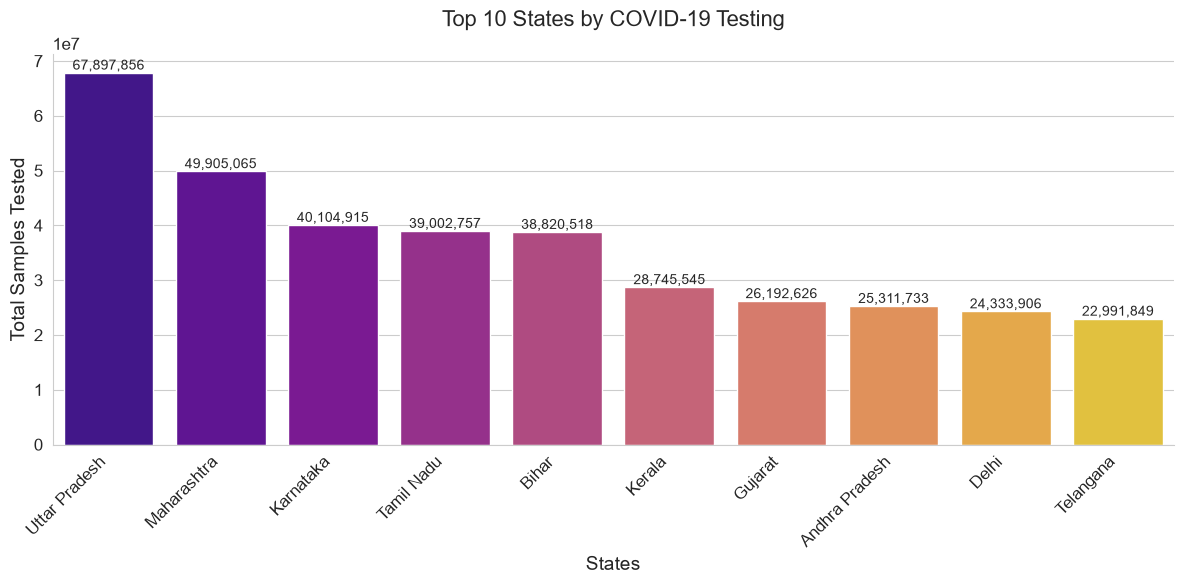

In [5]:
# ---------------------------------------------------------
# STEP 1: Load the COVID-19 testing dataset
# ---------------------------------------------------------

# pd.read_csv() reads the CSV file and stores it
# inside a Pandas DataFrame named df_testing.
df_testing = pd.read_csv("StatewiseTestingDetails.csv")


# ---------------------------------------------------------
# STEP 2: Convert the Date column into datetime format
# ---------------------------------------------------------

# pd.to_datetime() converts the values in the "Date" column
# from text format into proper Python datetime values.
# This allows Python to arrange the dates correctly from oldest to latest.
df_testing["Date"] = pd.to_datetime(df_testing["Date"])


# ---------------------------------------------------------
# STEP 3: Get the latest testing record for every state
# ---------------------------------------------------------

# sort_values("Date") arranges all rows according to date,
# starting from the oldest date and ending with the latest date.
# groupby("State") creates a separate group for each state.
# tail(1) selects the last row from every state group.
# Since the data was sorted by date, the last row represents the latest available testing record for that state.
latest_testing = (df_testing.sort_values("Date").groupby("State").tail(1))


# ---------------------------------------------------------
# STEP 4: Select the top 10 states by total samples tested
# ---------------------------------------------------------

# nlargest(10, "TotalSamples") selects the 10 rows having the highest values in the "TotalSamples" column.
# The result is stored in the top10_testing DataFrame.
top10_testing = latest_testing.nlargest(10,"TotalSamples")


# ---------------------------------------------------------
# STEP 5: Create the figure and plotting area
# ---------------------------------------------------------

# plt.subplots() creates:
# fig -> the complete chart or figure
# ax  -> the plotting area where the bars will be displayed
# figsize=(12, 6) makes the graph wider and easier to read.
fig, ax = plt.subplots(figsize=(12, 6))


# ---------------------------------------------------------
# STEP 6: Create the bar graph
# ---------------------------------------------------------

# sns.barplot() creates a bar chart.
# x="State" places state names on the horizontal axis.
# y="TotalSamples" places total testing values on the vertical axis.
# data=top10_testing tells Seaborn which DataFrame to use.
# palette="plasma" applies different colours to the bars.
# ax=ax draws the bar chart inside the plotting area created above.
# The completed bar plot is stored in the variable bars.
bars = sns.barplot(x="State",y="TotalSamples",data=top10_testing,palette="plasma",ax=ax)


# ---------------------------------------------------------
# STEP 7: Add the graph title
# ---------------------------------------------------------

# set_title() adds the main heading to the graph.
# fontsize=16 controls the title size.
# pad=20 adds space between the title and the graph.
ax.set_title("Top 10 States by COVID-19 Testing",fontsize=16,pad=20)


# ---------------------------------------------------------
# STEP 8: Add the x-axis label
# ---------------------------------------------------------

# The x-axis contains the names of the states.
ax.set_xlabel("States",fontsize=14)


# ---------------------------------------------------------
# STEP 9: Add the y-axis label
# ---------------------------------------------------------

# The y-axis shows the total number of samples tested.
ax.set_ylabel("Total Samples Tested",fontsize=14)


# ---------------------------------------------------------
# STEP 10: Rotate the state names
# ---------------------------------------------------------

# rotation=45 rotates each state name by 45 degrees.
# ha="right" aligns the labels toward the right. This prevents long state names from overlapping.
plt.xticks(rotation=45,ha="right")


# ---------------------------------------------------------
# STEP 11: Add values above every bar
# ---------------------------------------------------------

# bars.patches contains all the individual bars created in the bar graph.
# The loop processes one bar at a time.
for bar in bars.patches:

    # get_height() gives the height of the current bar.
    # In this graph, the height represents TotalSamples.
    height = bar.get_height()

    # ax.text() displays text at a particular position.
    ax.text(
        # Calculate the horizontal centre of the bar.
        bar.get_x() + bar.get_width() / 2,

        # Place the value at the top of the bar.
        height,

        # Format the value with commas and no decimal places.
        # Example: 25000000 becomes 25,000,000.
        f"{height:,.0f}",

        # Horizontally align the text at the centre.
        ha="center",

        # Vertically place the text just above the bar.
        va="bottom",

        # Set the size of the value label.
        fontsize=10
    )


# ---------------------------------------------------------
# STEP 12: Remove unnecessary graph borders
# ---------------------------------------------------------

# sns.despine() removes the top and right borders
# to give the chart a cleaner appearance.
sns.despine()


# ---------------------------------------------------------
# STEP 13: Adjust the graph spacing
# ---------------------------------------------------------

# tight_layout() automatically adjusts the spacing. It prevents the title, labels, and state names from overlapping or being cut off.
plt.tight_layout()


# ---------------------------------------------------------
# STEP 14: Display the completed graph
# ---------------------------------------------------------

# plt.show() displays the final bar graph.
plt.show()

### Insights (Testing Statistics)
- **Testing Leadership**: States with larger populations and better healthcare systems tend to conduct more tests
- **Correlation with Cases**: Higher testing numbers often correlate with higher confirmed case counts, as more cases are detected
- **Public Health Response**: Extensive testing indicates a proactive approach to monitoring and controlling the pandemic

## Q5. Which top 10 Indian states or union territories recorded the highest COVID-19 positivity rates on their latest available reporting date?
***Dataset: StatewiseTestingDetails.csv***

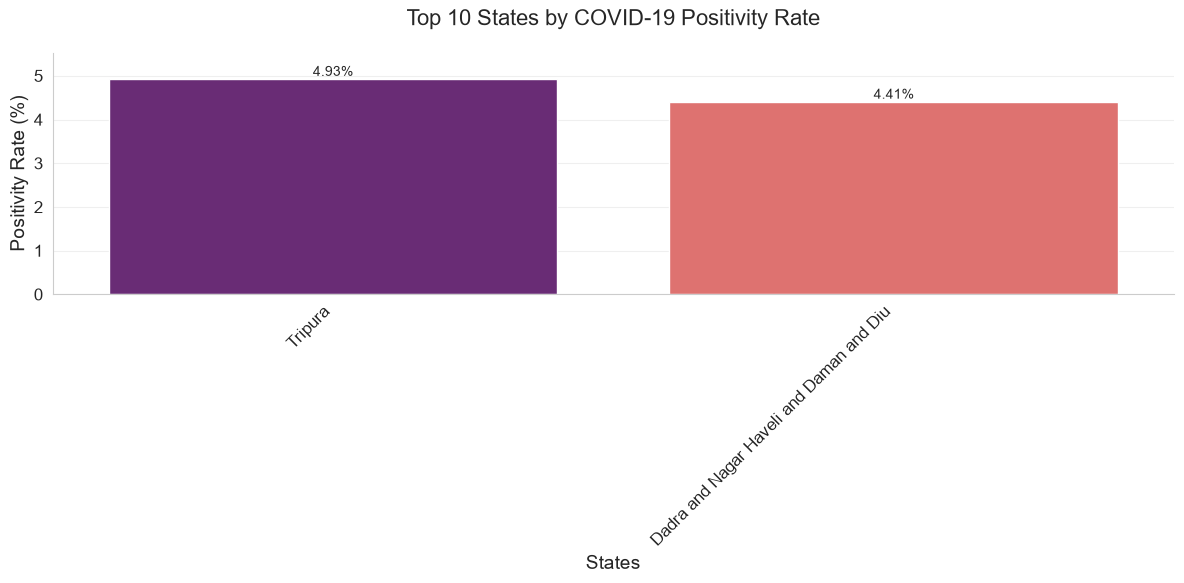

In [6]:
# ---------------------------------------------------------
# STEP 1: Remove rows with missing testing information
# ---------------------------------------------------------

# dropna() removes rows where important values are missing.
# subset=["Positive", "TotalSamples"] means that Pandas checks only the "Positive" and "TotalSamples" columns.
# .copy() creates a separate DataFrame and prevents SettingWithCopyWarning when we create a new column later.
latest_testing_clean = latest_testing.dropna(subset=["Positive", "TotalSamples"]).copy()


# ---------------------------------------------------------
# STEP 2: Remove rows where TotalSamples is zero
# ---------------------------------------------------------

# Positivity rate requires division by TotalSamples.
# Division by zero is not possible, so rows containing zero total samples are removed.
latest_testing_clean = latest_testing_clean[latest_testing_clean["TotalSamples"] > 0]


# ---------------------------------------------------------
# STEP 3: Calculate the COVID-19 positivity rate
# ---------------------------------------------------------

# Positivity Rate formula:
# Positivity Rate = (Positive Cases / Total Samples Tested) × 100
# A new column named "Positivity Rate" is created inside the latest_testing_clean DataFrame.
latest_testing_clean["Positivity Rate"] = (latest_testing_clean["Positive"] / latest_testing_clean["TotalSamples"]) * 100


# ---------------------------------------------------------
# STEP 4: Select the top 10 states
# ---------------------------------------------------------

# nlargest() selects the 10 rows with the highest values in the "Positivity Rate" column.
# The result is automatically arranged from the highest positivity rate to the lowest.
top10_positivity = latest_testing_clean.nlargest(10,"Positivity Rate")


# ---------------------------------------------------------
# STEP 5: Create the figure and plotting area
# ---------------------------------------------------------

# plt.subplots() creates:
# fig -> the complete figure or chart
# ax  -> the plotting area where the bars are drawn
# figsize=(12, 6) makes the graph larger and easier to read.
fig, ax = plt.subplots(figsize=(12, 6))


# ---------------------------------------------------------
# STEP 6: Create the positivity-rate bar graph
# ---------------------------------------------------------

# sns.barplot() creates a bar chart.
# x="State": Places state names on the horizontal x-axis.
# y="Positivity Rate": Uses positivity-rate values as bar heights.
# data=top10_positivity: Tells Seaborn which DataFrame to use.
# hue="State": Assigns a separate colour to each state.
# palette="magma": Uses the Magma colour palette.
# legend=False: Prevents an unnecessary legend because state names are already displayed on the x-axis.
# ax=ax: Draws the chart inside the axes created above.
bars = sns.barplot(
    x="State",
    y="Positivity Rate",
    data=top10_positivity,
    hue="State",
    palette="magma",
    legend=False,
    ax=ax
)


# ---------------------------------------------------------
# STEP 7: Add the title
# ---------------------------------------------------------

# set_title() adds the main heading.
# fontsize=16 controls the title size.
# pad=20 adds space between the title and the graph.
ax.set_title( "Top 10 States by COVID-19 Positivity Rate",fontsize=16,pad=20)


# ---------------------------------------------------------
# STEP 8: Add the x-axis label
# ---------------------------------------------------------

# The x-axis contains the names of the states.
ax.set_xlabel("States",fontsize=14)


# ---------------------------------------------------------
# STEP 9: Add the y-axis label
# ---------------------------------------------------------

# The y-axis contains positivity-rate percentages.
ax.set_ylabel("Positivity Rate (%)",fontsize=14)


# ---------------------------------------------------------
# STEP 10: Rotate the state names
# ---------------------------------------------------------

# rotation=45 rotates the labels by 45 degrees.
# ha="right" means horizontal alignment is set to the right.
# This prevents long state names from overlapping.
plt.xticks(rotation=45,ha="right")


# ---------------------------------------------------------
# STEP 11: Add percentage labels above the bars
# ---------------------------------------------------------

# bars.patches contains all rectangular bars in the chart.
# The loop processes one bar at a time.
for bar in bars.patches:

    # get_height() returns the height of the current bar.
    # Here, the height represents the positivity rate.
    height = bar.get_height()

    # ax.text() places text at a selected position.
    ax.text(
        # Find the horizontal centre of the bar.
        bar.get_x() + bar.get_width() / 2,

        # Place the text at the top of the bar.
        height,

        # Display the positivity rate with two decimal places
        # followed by a percentage symbol.
        # Example: 12.3456 becomes 12.35%.
        f"{height:.2f}%",

        # Centre the text horizontally.
        ha="center",

        # Place the bottom of the text above the bar.
        va="bottom",

        # Set the text size.
        fontsize=10
    )


# ---------------------------------------------------------
# STEP 12: Add some extra space above the tallest bar
# ---------------------------------------------------------

# The y-axis limit is increased slightly so that
# the value labels are not cut off at the top.
ax.set_ylim(0, top10_positivity["Positivity Rate"].max() * 1.12)


# ---------------------------------------------------------
# STEP 13: Add light horizontal grid lines
# ---------------------------------------------------------

# axis="y" adds grid lines only along the y-axis.
# alpha=0.3 makes the grid lines light.
ax.grid(axis="y", alpha=0.3)


# ---------------------------------------------------------
# STEP 14: Remove unnecessary borders
# ---------------------------------------------------------

# sns.despine() removes the top and right borders.
# This gives the graph a cleaner appearance.
sns.despine()


# ---------------------------------------------------------
# STEP 15: Adjust the layout
# ---------------------------------------------------------

# tight_layout() automatically adjusts spacing so that
# titles, labels, and state names are not cut off.
plt.tight_layout()


# ---------------------------------------------------------
# STEP 16: Display the completed graph
# ---------------------------------------------------------

# plt.show() displays the final graph.
plt.show()

### Insights (Positivity Rate)
- **Transmission Indicator**: Positivity rate indicates how widespread transmission is in a region
- **High vs Low**: States with high positivity rates may have more active transmission, while lower rates suggest better control
- **Testing Adequacy**: Very high positivity rates (>10%) may indicate insufficient testing relative to the true number of infections